In [10]:
# shell
# python -m venv .venv       

# In cmd.exe
# .venv\Scripts\activate.bat

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
from tqdm.notebook import tqdm

import torch
import torch.nn.functional as F
from torch import nn
from torch import Tensor
from einops import rearrange, repeat
from einops.layers.torch import Rearrange

In [65]:
import myVAE
importlib.reload(myVAE)

from myVAE import VAE

In [13]:
# https://www.kaggle.com/datasets/infamouscoder/dataset-netflix-shows
# https://www.kaggle.com/code/samad0015/eda-on-netflix-shows
path = "../data/netflix_titles.csv"
df = pd.read_csv(path)

df.shape

(8807, 12)

In [14]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [15]:
states = []

for line in df['country'].unique():
    if pd.isna(line):
        states.append("undefined")
        continue 
    for state in line.replace(", ", ",").split(","):
        states.append(state)


np.unique(np.array(states))

array(['', 'Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina',
       'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas',
       'Bangladesh', 'Belarus', 'Belgium', 'Bermuda', 'Botswana',
       'Brazil', 'Bulgaria', 'Burkina Faso', 'Cambodia', 'Cameroon',
       'Canada', 'Cayman Islands', 'Chile', 'China', 'Colombia',
       'Croatia', 'Cuba', 'Cyprus', 'Czech Republic', 'Denmark',
       'Dominican Republic', 'East Germany', 'Ecuador', 'Egypt',
       'Ethiopia', 'Finland', 'France', 'Georgia', 'Germany', 'Ghana',
       'Greece', 'Guatemala', 'Hong Kong', 'Hungary', 'Iceland', 'India',
       'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Italy',
       'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Kuwait',
       'Latvia', 'Lebanon', 'Liechtenstein', 'Lithuania', 'Luxembourg',
       'Malawi', 'Malaysia', 'Malta', 'Mauritius', 'Mexico', 'Mongolia',
       'Montenegro', 'Morocco', 'Mozambique', 'Namibia', 'Nepal',
       'Netherlands', 'New Zealand', 'Ni

Try GPT

In [16]:
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM
import tqdm

model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# Set pad token to eos_token to avoid warning
tokenizer.pad_token = tokenizer.eos_token

prompt = "Brad Pitt"

inputs = tokenizer(prompt, return_tensors="pt", padding=True, return_attention_mask=True)

with torch.no_grad():
    outputs = model.generate(
        inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        pad_token_id=tokenizer.eos_token_id,
        max_new_tokens=50,
        do_sample=True,  # optional: adds randomness
        top_k=50,
        top_p=0.95
    )

response = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(response)



c:\Users\david\Documents\GitHub\MLOpsProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Brad Pitt is trying to make it a "must-have" on this list

- Chris Wesseling (The Real Ghostbusters #5) – It's always nice to have a list, but The Real Ghostbusters has been a must-have for me


Without context

In [17]:
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# Tokenize input
texts = ["Brad Pitt", "Edward Norton", "Helena Bonham Carter"]
inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True)

# Pass token IDs into the embedding layer directly
token_ids = inputs["input_ids"]  # shape: (batch_size, seq_len)
token_embeddings = model.get_input_embeddings()(token_ids)  # shape: (batch_size, seq_len, hidden_size)

# Optional: Mean pool across tokens
sentence_embeddings = token_embeddings.mean(dim=1)

print("Embedding shape:", sentence_embeddings.shape)  # e.g., torch.Size([3, 768])


Embedding shape: torch.Size([3, 768])


With context

In [18]:

# Load a BERT model (for embeddings)
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# List of strings (e.g. actor names)
texts = ["Brad Pitt", "Edward Norton", "Helena Bonham Carter"]

# Tokenize
inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True)

# Disable gradient tracking
with torch.no_grad():
    outputs = model(**inputs)
    token_embeddings = outputs.last_hidden_state  # shape: (batch_size, seq_len, hidden_dim)

# Mean pool over tokens (dim=1)
sentence_embeddings = token_embeddings.mean(dim=1)

print("Embedding shape:", sentence_embeddings.shape)  # torch.Size([3, 768])

Embedding shape: torch.Size([3, 768])


In [ ]:
# Load a BERT model (for embeddings)
model_name = "bert-base-uncased"
# tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

<br>

EMB

In [206]:
states_emb = []

for i, line in enumerate(df['country']):
    text = "movie county is unknown" if pd.isna(line) else "movie produced in " + line
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)

    with torch.no_grad():
        outputs = model(**inputs)
        token_embeddings = outputs.last_hidden_state  # shape: (batch_size, seq_len, hidden_dim)
        last_embedding = token_embeddings[0, -1]

    # sentence_embeddings = token_embeddings.mean(dim=1).squeeze()   # Mean pool over tokens (dim=1)

    sentence_embeddings = last_embedding
    states_emb.append(sentence_embeddings)
    print("\r", f"iteration {i+1} / {len(df['country'])}: \t {token_embeddings.shape} \t {text} ", end=' '*100)


 iteration 8807 / 8807: 	 torch.Size([1, 6, 768]) 	 movie produced in India                                                                                                                                                                                                                            

VAE

In [207]:
from torch.utils.data import DataLoader

import myVAE
importlib.reload(myVAE)

from myVAE import VAE

In [208]:
vae = VAE(states_emb[0].shape[0], 4)

In [209]:
epochs = 8
optimizer = torch.optim.Adam(vae.parameters(), lr = 0.001)
print(sum(p.numel() for p in vae.parameters())/1e3, 'K parameters')

741.512 K parameters


In [210]:
train_loader = DataLoader(states_emb, shuffle=True, batch_size=32)

In [211]:
for epoch in range(epochs):
    vae.train()
    for x in train_loader:
        x = x.view(-1, vae.in_dim)
        
        x_hat, mu, log_var = vae(x)
        loss = vae.loss(x_hat, mu, log_var, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    print(f"epoch: {epoch + 1} / {epochs} \t loss: {loss}")   

epoch: 1 / 8 	 loss: 3.3195719718933105
epoch: 2 / 8 	 loss: 5.3713788986206055
epoch: 3 / 8 	 loss: 3.475773572921753
epoch: 4 / 8 	 loss: 3.5011048316955566
epoch: 5 / 8 	 loss: 3.5827908515930176
epoch: 6 / 8 	 loss: 4.2873311042785645
epoch: 7 / 8 	 loss: 4.830394268035889
epoch: 8 / 8 	 loss: 4.398200511932373


In [212]:
X = torch.stack(states_emb)

In [100]:
from sklearn.manifold import TSNE

In [213]:
X_np = vae.encode(X)[0].detach().numpy()

In [214]:
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=40)

X_tsne = tsne.fit_transform(X_np)

In [232]:
choose_state = np.zeros(df.shape[0], dtype='int32')
for i, line in enumerate(df['country']):
    if not pd.isna(line) and "United States" in line:
        choose_state[i] = 1

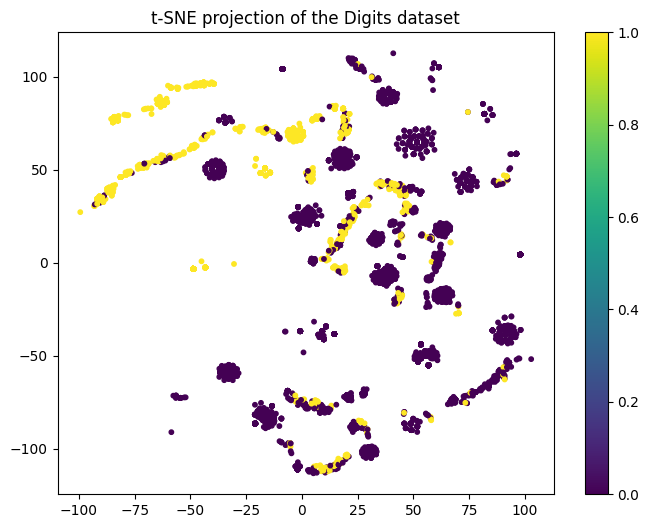

In [233]:
# Plot
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=choose_state, s=10)
plt.colorbar()
plt.title("t-SNE projection of the Digits dataset")
plt.show()

In [230]:
distances = np.sum((X_np[0] - X_np[:1060])**2, axis = 1)
idx = np.argsort(distances)


In [231]:
for i in idx:
    print(f"{i} \t distance: {np.sqrt(distances[i])*10: .4f} \t country: {df['country'][i]}") 

342 	 distance:  0.0000 	 country: United States
1036 	 distance:  0.0000 	 country: United States
1039 	 distance:  0.0000 	 country: United States
1042 	 distance:  0.0000 	 country: United States
40 	 distance:  0.0000 	 country: United States
41 	 distance:  0.0000 	 country: United States
42 	 distance:  0.0000 	 country: United States
43 	 distance:  0.0000 	 country: United States
44 	 distance:  0.0000 	 country: United States
48 	 distance:  0.0000 	 country: United States
1011 	 distance:  0.0000 	 country: United States
657 	 distance:  0.0000 	 country: United States
660 	 distance:  0.0000 	 country: United States
662 	 distance:  0.0000 	 country: United States
667 	 distance:  0.0000 	 country: United States
15 	 distance:  0.0000 	 country: United States
9 	 distance:  0.0000 	 country: United States
27 	 distance:  0.0000 	 country: United States
1015 	 distance:  0.0000 	 country: United States
1024 	 distance:  0.0000 	 country: United States
1026 	 distance:  0.0000